<a href="https://colab.research.google.com/github/Kavyagupta07/fake_news_verifier/blob/main/model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Kavyagupta07/fake_news_verifier.git

fatal: destination path 'fake_news_verifier' already exists and is not an empty directory.


In [ ]:
%cd fake_news_verifier

/content/fake_news_verifier


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install \
    cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com


In [ ]:
import cudf
import cupy as cp
from cuml.linear_model import LogisticRegression

print("cuML working")

cuML working


In [ ]:
import cudf

df = cudf.read_parquet(
    "/content/drive/MyDrive/datasets/df_embedded.parquet"
)

print(df.head())

                                               title  \
0  [0.0270843505859375, -0.00576019287109375, -0....   
1  [-0.040557861328125, -0.0083465576171875, -0.0...   
2  [0.00545501708984375, -0.01433563232421875, -0...   
3  [-0.0421142578125, 0.00812530517578125, -0.008...   
4  [-0.029876708984375, 0.051483154296875, -0.019...   

                                                text  \
0  [0.043548583984375, 0.030487060546875, -0.0671...   
1  [-0.03948974609375, -0.006710052490234375, -0....   
2  [-0.0298614501953125, -0.006389617919921875, -...   
3  [-0.0215911865234375, -0.01253509521484375, -0...   
4  [-0.0201873779296875, 0.0237274169921875, -0.0...   

                                             subject  label  
0  [-0.016265869140625, 0.0360107421875, -0.04830...      0  
1  [-0.016265869140625, 0.0360107421875, -0.04830...      0  
2  [0.00534820556640625, 0.035797119140625, -0.03...      0  
3  [-0.039947509765625, 0.0254974365234375, -0.01...      0  
4  [-0.003187179

In [ ]:
print(df.columns)

Index(['title', 'text', 'subject', 'label'], dtype='object')


In [ ]:
import cudf
import cupy as cp

In [ ]:
print(df.dtypes)

title       list
text        list
subject     list
label      int32
dtype: object


In [ ]:
X = df.drop(columns=["label"])
y = df["label"]

In [ ]:
import cupy as cp

In [ ]:
title_emb = cp.array(
    df["title"].to_arrow().to_pylist()
)

In [ ]:
text_emb = cp.array(
    df["text"].to_arrow().to_pylist()
)

In [ ]:
subject_emb = cp.array(
    df["subject"].to_arrow().to_pylist()
)

In [ ]:
y = df["label"]

In [ ]:
print(X.shape)
print(y.shape)

(44898, 3)
(44898,)


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 103


In [ ]:
print(df["label"].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


In [ ]:
unique_text = len(set(map(tuple, text_emb.get())))

print("Unique text embeddings:", unique_text)
print("Total rows:", len(text_emb))

Unique text embeddings: 38682
Total rows: 44898


In [ ]:
X = text_emb
y = df["label"]

In [ ]:
from sklearn.utils import shuffle

df = shuffle(df, random_state=42)

In [ ]:
import pandas as pd

In [ ]:
temp_df = pd.DataFrame({
    "embedding": list(text_emb.get()),
    "label": y.to_pandas()
})

In [ ]:
temp_df["embedding"] = temp_df["embedding"].apply(tuple)

In [ ]:
temp_df = temp_df.drop_duplicates(subset=["embedding"])

In [ ]:
print(temp_df.shape)

(38682, 2)


In [ ]:
X_clean = cp.array(temp_df["embedding"].tolist())

y_clean = temp_df["label"].values

In [ ]:
X_reduced = X_clean[:, :580]

In [ ]:
from cuml.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y_clean,
    test_size=0.2,
    random_state=42
)

In [ ]:
from cuml.linear_model import LogisticRegression

model = LogisticRegression(
    C=0.001
)

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
preds = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

try:
    y_pred = preds.get()
except:
    y_pred = preds

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9241308000516997


In [ ]:
!pip install sentence-transformers

In [ ]:
import joblib

joblib.dump(model, "fake_news_model.pkl")

['fake_news_model.pkl']

In [ ]:
!cp fake_news_model.pkl /content/drive/MyDrive/

In [ ]:
model = joblib.load(
    "/content/drive/MyDrive/fake_news_model.pkl"
)

In [ ]:
import cupy as cp

def predict_fake_news(news_text):

    # Generate embedding
    embedding = embedding_model.encode(news_text)

    # Convert to GPU array
    embedding = cp.array([embedding])

    # Apply same feature reduction
    embedding = embedding[:, :580]

    # Predict
    prediction = model.predict(embedding)

    try:
        prediction = prediction.get()
    except:
        pass

    # Output
    if prediction[0] == 1:
        return "FAKE NEWS"
    else:
        return "REAL NEWS"

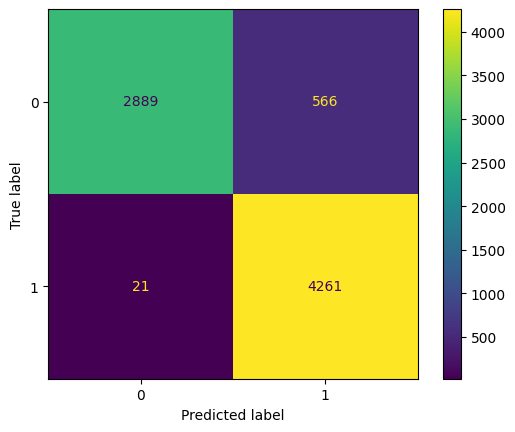

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9241308000516997


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.84      0.91      3455
           1       0.88      1.00      0.94      4282

    accuracy                           0.92      7737
   macro avg       0.94      0.92      0.92      7737
weighted avg       0.93      0.92      0.92      7737



In [ ]:
from sklearn.metrics import confusion_matrix

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

[[2889  566]
 [  21 4261]]


In [ ]:
from sentence_transformers import SentenceTransformer
import cupy as cp
import joblib

In [ ]:
embedding_model = SentenceTransformer(
    'BAAI/bge-large-en'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-large-en
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
test_embedding = embedding_model.encode("hello world")

print(len(test_embedding))

1024


In [ ]:
model = joblib.load(
    "/content/drive/MyDrive/fake_news_model.pkl"
)

In [ ]:
def predict_fake_news(news_text):

    # Generate embedding
    embedding = embedding_model.encode(news_text)

    # Convert to GPU array
    embedding = cp.array([embedding])

    # Match training dimensions
    embedding = embedding[:, :580]

    # Predict
    prediction = model.predict(embedding)

    try:
        prediction = prediction.get()
    except:
        pass

    if prediction[0] == 1:
        return "FAKE NEWS"
    else:
        return "REAL NEWS"

In [ ]:
sample_news = """
Government announces new AI policy for education sector.
"""

print(
    predict_fake_news(sample_news)
)

FAKE NEWS


# **SWM**

In [ ]:
from cuml.svm import SVC

In [ ]:
X_cpu = X_reduced.get()

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

svm_cv_model = LinearSVC(
    C=0.0001,
    max_iter=1000
)

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

svm_scores = cross_val_score(
    svm_cv_model,
    X_cpu,
    y_clean,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1
)

print("Fold Scores:", svm_scores)

print(
    "Mean SVM Accuracy:",
    svm_scores.mean()
)

Fold Scores: [0.89543751 0.89168929 0.89568252 0.89775078 0.89374354]
Mean SVM Accuracy: 0.8948607257809377


In [ ]:
svm_accuracy = svm_scores.mean()

# Random Forest

In [ ]:
from cuml.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=10,
    max_depth=3,
    max_features=0.2,
    random_state=30
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier()

In [ ]:
rf_preds = rf_model.predict(X_test)

In [ ]:
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

try:
    rf_preds_cpu = rf_preds.get()
except:
    rf_preds_cpu = rf_preds

rf_accuracy = accuracy_score(
    y_test,
    rf_preds_cpu
)

print("RF Accuracy:", rf_accuracy)

RF Accuracy: 0.9365387100943519


# **XGBoost**

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
X_train_cpu = X_train.get()
X_test_cpu = X_test.get()

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=10,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=30
)

xgb_model.fit(
    X_train_cpu,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=10,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_preds = xgb_model.predict(X_test_cpu)

In [ ]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_preds
)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.9353754685278531


comparison table:

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.9241,
        svm_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.924100
1                  SVM  0.894861
2        Random Forest  0.936539
3              XGBoost  0.935375


**ACCURACY COMPARISON GRAPH**

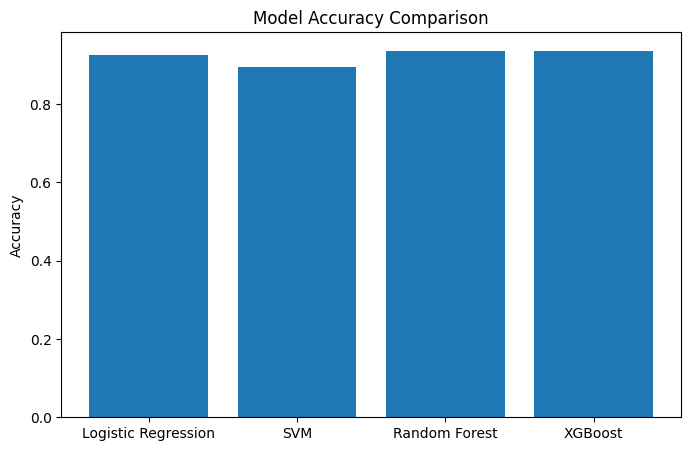

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

 **DATASET DISTRIBUTION GRAPH**

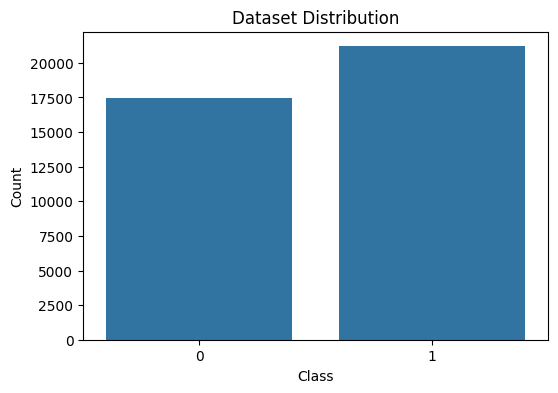

In [ ]:
import seaborn as sns

label_counts = pd.Series(y_clean).value_counts()

plt.figure(figsize=(6,4))

sns.barplot(
    x=label_counts.index,
    y=label_counts.values
)

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Dataset Distribution")

plt.show()